In [ ]:

import os,sys
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import zray 
import gpoloidal
import gpoloidal.plot_utils as plot_utils
import gpoloidal.rt1 as rt1

plot_utils.journal_mode()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
rt1kernel = rt1.Kernel2D_scatter_rt1()

load vessel from C:\Users\ueda\github_project\GPoloidal\src\gpoloidal\rt1\rt1_simple_frame.json
you have to "create_induced_point()" or "load_point()" in advance!



fill_start_point is None, so use (np.float64(0.5445500000030501), np.float64(0.002483005624657039))


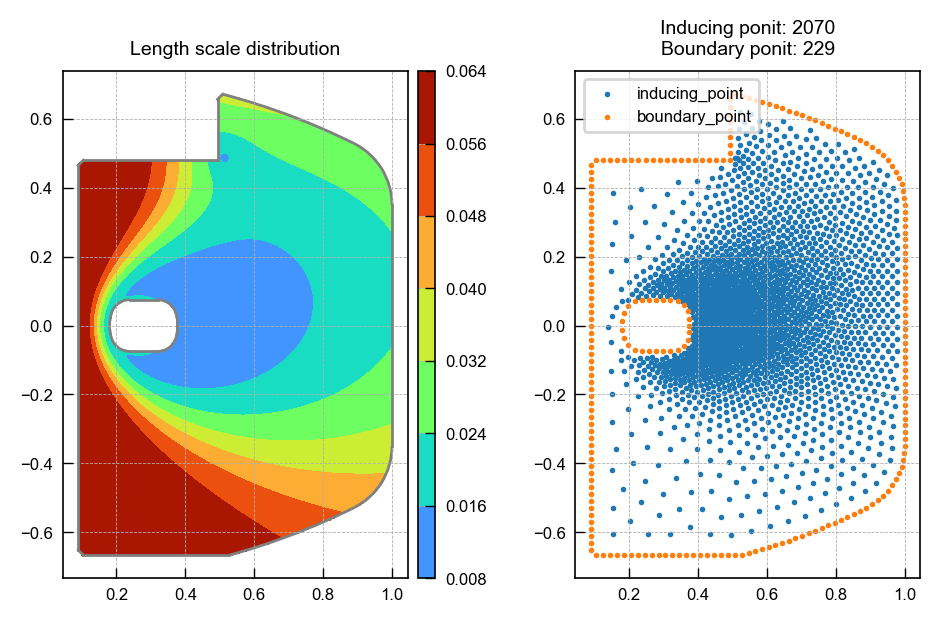

In [ ]:
rt1kernel.load_point(**np.load('point_temp.npz'),length_sq_fuction=rt1.phantom.Length_scale_sq,is_plot=True)

In [ ]:
rt1_vessel = zray.vessel.get_rt1_vessel()

c:\Users\ueda\github_project\GPoloidal\.venv\Lib\site-packages\dxfgrabber\dxfentities.py:856: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  return self.raw_text.split('\P')


In [ ]:
camera = zray.measurement.Camera2D_rphiz(
    focal_length=0.01 ,                        # 焦点距離 [m]（例）
    location=(1.2, 0.0, 0),   # 例：x=150 の位置
    center_angles=(23,0),
    sensor_size=( 0.0082,0.0082),                 # センサーサイズ [mm]（例）
    resolution=(200, 200),                      # 解像度
    rotation=-0/180*np.pi,                          # センサーの回転角度
)

raymodel=  zray.Raytracing(rt1_vessel,camera)
raymodel.save_setting("model")

focal_length: 0.01
sensor_size: (0.0082, 0.0082)
resolution: (200, 200)
location: [1.2 0.  0. ]
center_angles: (23, 0)
rotation: 0.0
im_shape: (200, 200)
_Camera2D_rphiz__M: 40000


100%|██████████| 20/20 [00:06<00:00,  3.31it/s]


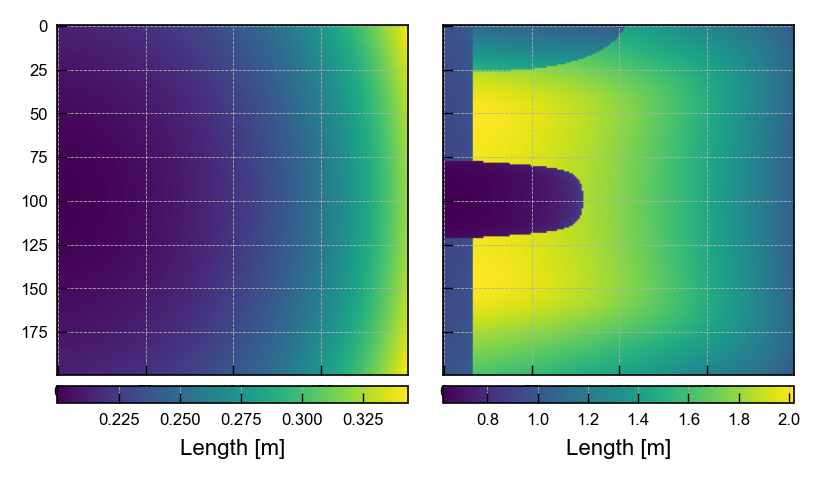

In [21]:
raymodel.main(nreflections=1,pass_through_first=True)
raymodel.plot()

In [ ]:
r_plot = np.linspace(0.05,1.05,501)
z_plot = np.linspace(-0.7,0.7,501)
rt1kernel.set_grid_interface(r_plot,z_plot)

medium grid: 156 x 219


C:\Users\ueda\github_project\GPoloidal\src\gpoloidal\rt1\mag.py:112: RuntimeWarning: invalid value encountered in divide
  bz = a*(h*fe/ff + fk)
C:\Users\ueda\github_project\GPoloidal\src\gpoloidal\rt1\mag.py:113: RuntimeWarning: divide by zero encountered in divide
  br = e*(g*fe/ff - fk)
C:\Users\ueda\github_project\GPoloidal\src\gpoloidal\rt1\mag.py:113: RuntimeWarning: invalid value encountered in subtract
  br = e*(g*fe/ff - fk)
C:\Users\ueda\github_project\GPoloidal\src\gpoloidal\rt1\mag.py:211: RuntimeWarning: invalid value encountered in add
  5.048895851e0 \



fill_start_point is None, so use (np.float64(0.5499999999999999), np.float64(3.2444873779000007e-17))

fill_start_point is None, so use (np.float64(0.55), np.float64(5.672995894292217e-17))


In [ ]:
func = rt1.phantom.get_phantom_funtion('double')

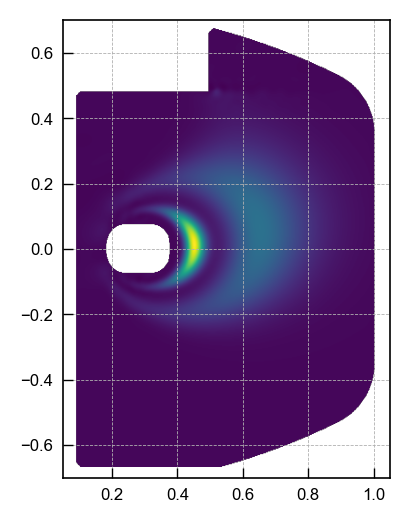

In [ ]:
rI,zI = rt1kernel.r_idc,rt1kernel.z_idc

f_HD = rt1kernel.convert_grid(func(rI,zI))
im_mask = rt1kernel.mask
im_kwargs = rt1kernel.im_kwargs


plt.imshow(f_HD*im_mask,**im_kwargs)

In [ ]:
rt1kernel.set_kernel(length_scale_factor=1.4)
rt1kernel.sampler()

Eigenvalue decomposition is recalculated


array([ 0.01178417, -0.1687046 ,  0.15306082, ...,  0.03853315,
       -1.15586853, -0.68893184], shape=(2070,))

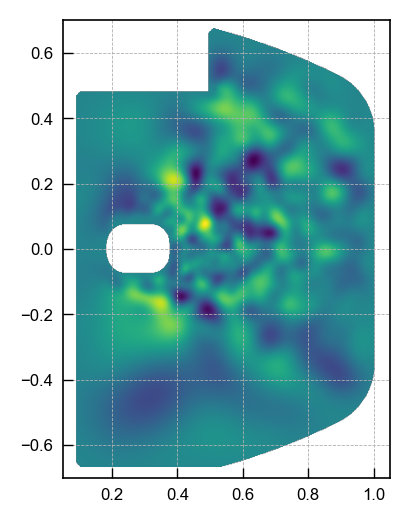

In [ ]:
f = rt1kernel.sampler()
f_HD = rt1kernel.convert_grid(f)
plt.imshow(f_HD*im_mask,**im_kwargs)

In [16]:
H2 = rt1kernel.create_obs_matrix_kernel_weighting(ray=raymodel.rays[1],Lnum=101)

100%|██████████| 40000/40000 [01:55<00:00, 346.55it/s]


In [36]:
H = rt1kernel.create_obs_matrix_kernel_interpolation(ray=raymodel.rays[1],Lnum=1001)

 31%|███       | 12330/40000 [16:15<36:28, 12.64it/s] 


KeyboardInterrupt: 

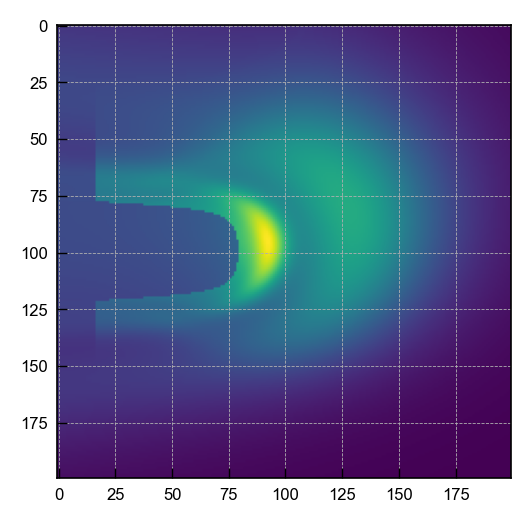

In [20]:
plt.imshow((H2 @ func(rI,zI).flatten()).reshape(200,200))

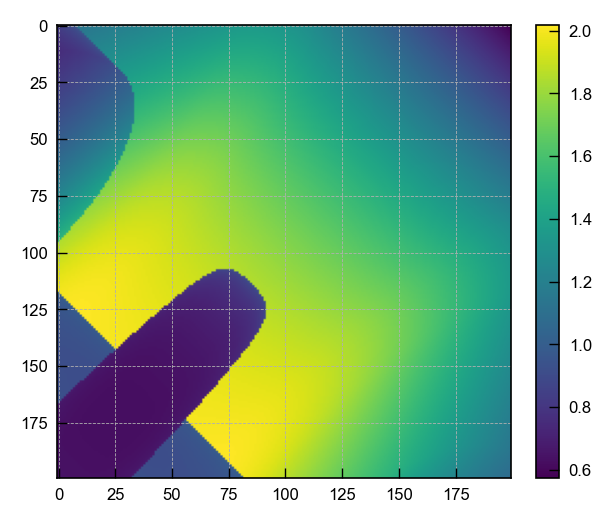

In [ ]:
plt.imshow(H2.sum(axis=1).reshape(200,200))

plt.colorbar(  )

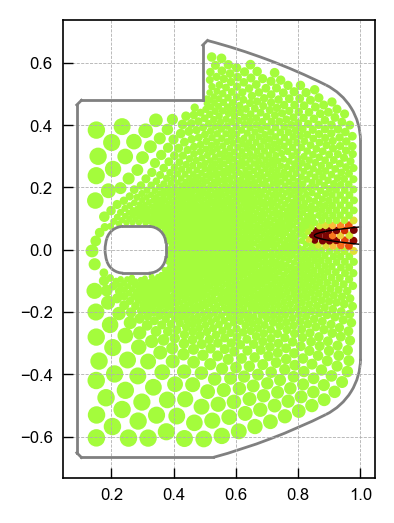

In [50]:
i = np.random.randint(0,10000)

r_ray,z_ray = raymodel.rays[1].generate_rz(Lnum=100)
plt.plot(r_ray[i,:],z_ray[i,:],'k-',lw=0.5)
plt.scatter(rt1kernel.r_idc,rt1kernel.z_idc,s=rt1kernel.ls_sq_idc*1e4*0.7,c=H2[i,:]/rt1kernel.ls_sq_idc,cmap='turbo',vmin=-100,vmax=100)




rt1_vessel.plot()

plt.gca().set_aspect('equal')


In [40]:
A = np.linalg.svd(H)

NameError: name 'H' is not defined

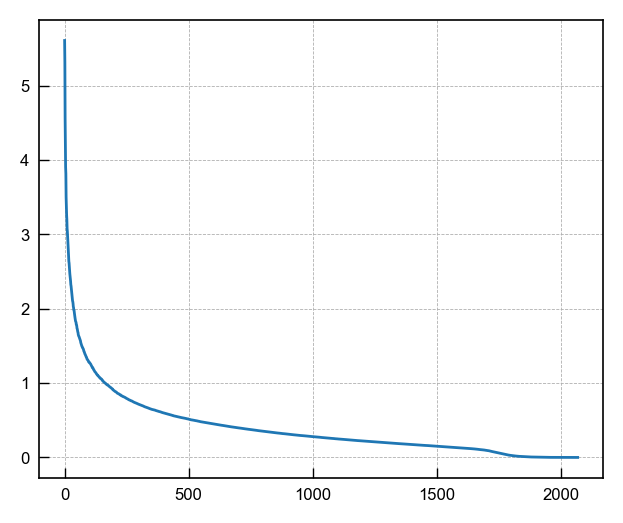

In [189]:
plt.plot(A.S)

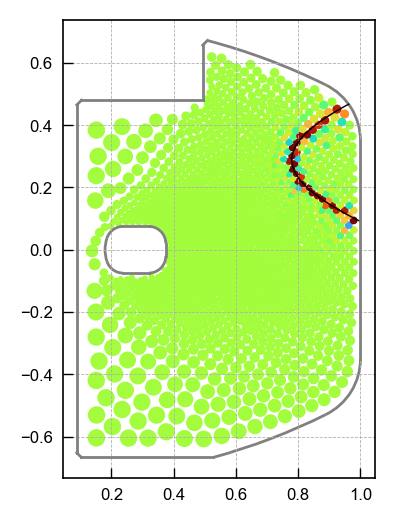

In [ ]:
i = np.random.randint(0,10000)

r_ray,z_ray = raymodel.rays[1].generate_rz(Lnum=100)
plt.plot(r_ray[i,:],z_ray[i,:],'k-',lw=0.5)
plt.scatter(rt1kernel.r_idc,rt1kernel.z_idc,s=rt1kernel.ls_sq_idc*1e4*0.7,c=H[i,:]/rt1kernel.ls_sq_idc,cmap='turbo',vmin=-100,vmax=100)




rt1_vessel.plot()

plt.gca().set_aspect('equal')


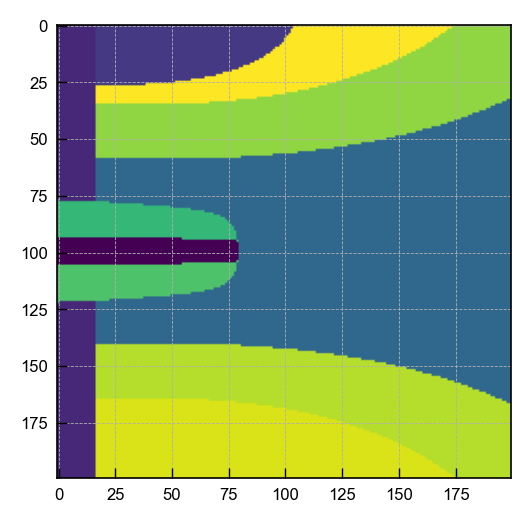

In [72]:
plt.imshow(raymodel.rays[1].curve_index.im)